In [3]:
import pandas as pd
df = pd.read_csv("C:/Users/SARKEENG/OneDrive/Telco_customer_churn.csv")
print(df.shape)
df.info()
print(df.head())
print(df["Churn"].value_counts(normalize=True))

(7043, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Serv

KeyError: 'Churn'

In [4]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
print("Missing Total Charges:", df["Total Charges"].isna().sum())

drop_cols = ["CustomerID", "Count", "Country", "State", "City", "Zip Code",
             "Lat Long", "Latitude", "Longitude",
             "Churn Value", "Churn Score", "CLTV", "Churn Reason"]
df = df.drop(columns=drop_cols)

df["Total Charges"] = df["Total Charges"].fillna(0)
df["Churn"] = (df["Churn Label"] == "Yes").astype(int)
df = df.drop(columns=["Churn Label"])

print(df.shape)
print(df["Churn"].value_counts(normalize=True))
df.info()

Missing Total Charges: 11
(7043, 20)
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract          

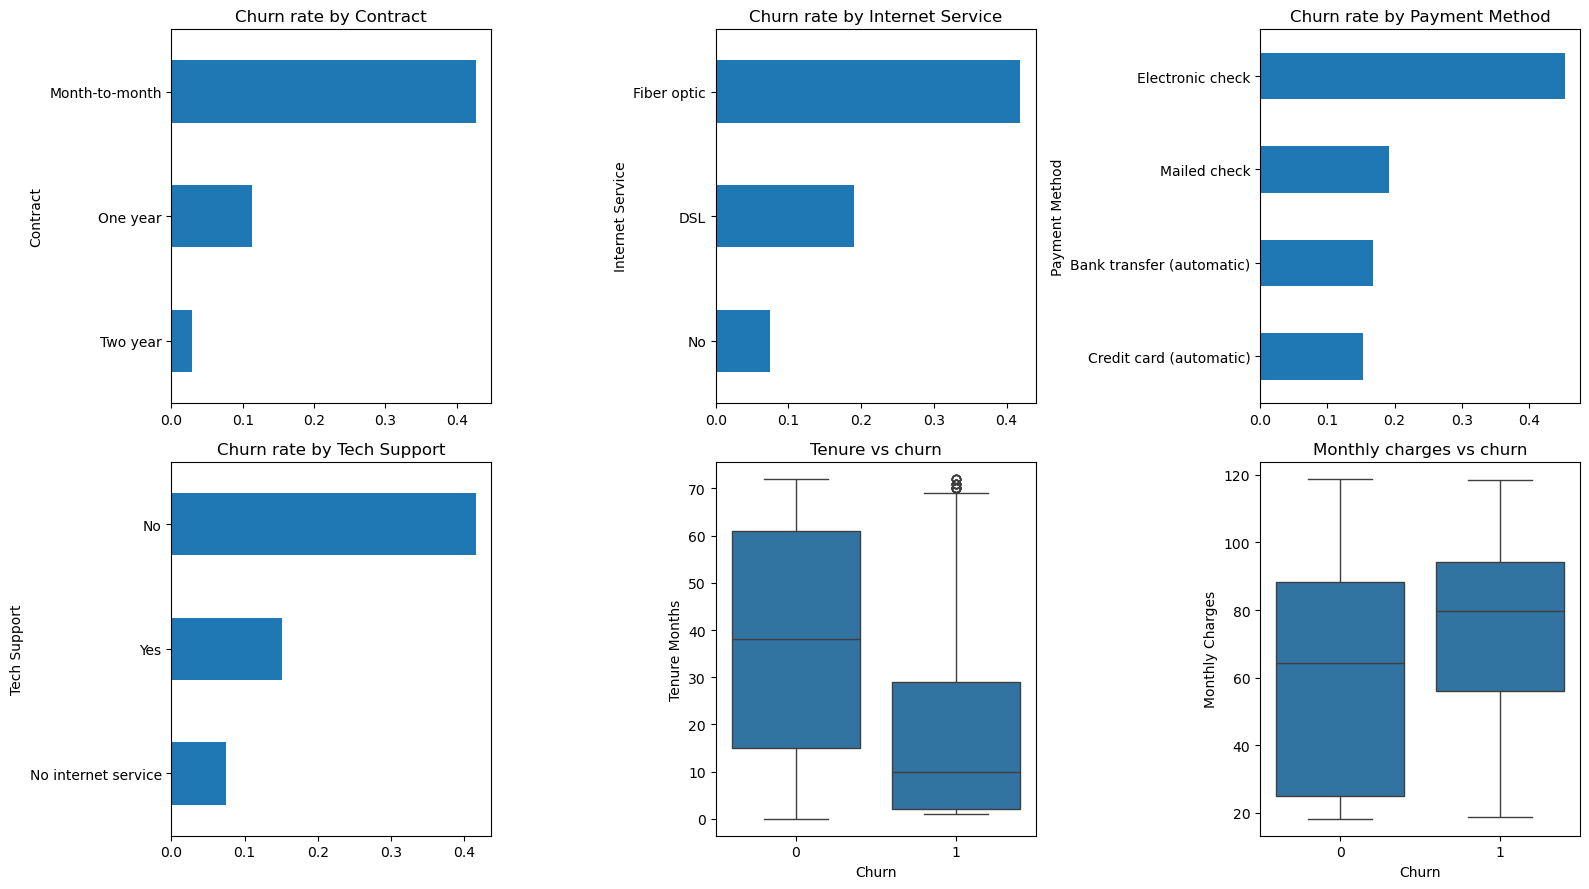

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flat[:4], ["Contract", "Internet Service", "Payment Method", "Tech Support"]):
    df.groupby(col)["Churn"].mean().sort_values().plot(kind="barh", ax=ax)
    ax.set_title(f"Churn rate by {col}")

sns.boxplot(x="Churn", y="Tenure Months", data=df, ax=axes[1, 1])
axes[1, 1].set_title("Tenure vs churn")

sns.boxplot(x="Churn", y="Monthly Charges", data=df, ax=axes[1, 2])
axes[1, 2].set_title("Monthly charges vs churn")

plt.tight_layout()
plt.show()

In [6]:
print(df.groupby("Contract")["Churn"].mean())
print(df.groupby("Churn")[["Tenure Months", "Monthly Charges"]].mean())

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64
       Tenure Months  Monthly Charges
Churn                                
0          37.569965        61.265124
1          17.979133        74.441332


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

X = df.drop(columns="Churn")
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
}

for name, model in models.items():
    pipe = Pipeline([("pre", pre), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    print(name)
    print(classification_report(y_test, pred))
    print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3), "\n")

Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC: 0.849 

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.835 



Best C: {'model__C': 5}
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC: 0.848


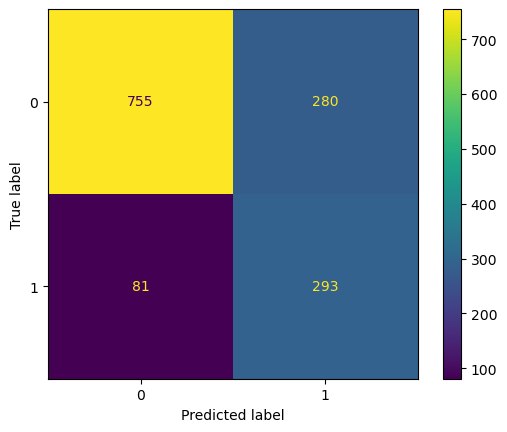

num__Monthly Charges                       -1.432837
num__Tenure Months                         -1.225073
cat__Dependents_Yes                        -0.967554
cat__Internet Service_DSL                  -0.865255
cat__Contract_Two year                     -0.783077
cat__Online Security_No internet service   -0.437983
cat__Internet Service_No                   -0.437983
cat__Online Backup_No internet service     -0.437983
dtype: float64
cat__Payment Method_Electronic check    0.216026
cat__Multiple Lines_Yes                 0.250950
cat__Streaming TV_Yes                   0.410370
cat__Streaming Movies_Yes               0.421003
num__Total Charges                      0.532129
cat__Contract_Month-to-month            0.638668
cat__Dependents_No                      0.670477
cat__Internet Service_Fiber optic       1.006160
dtype: float64


['churn_model.pkl']

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib

pipe = Pipeline([("pre", pre),
                 ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))])

grid = GridSearchCV(
    pipe,
    param_grid={"model__C": [0.01, 0.1, 0.5, 1, 5, 10]},
    scoring="roc_auc",
    cv=5,
)
grid.fit(X_train, y_train)
print("Best C:", grid.best_params_)

best = grid.best_estimator_
pred = best.predict(X_test)
proba = best.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred))
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))

ConfusionMatrixDisplay(confusion_matrix(y_test, pred)).plot()
plt.show()

# feature importance (coefficients)
names = best.named_steps["pre"].get_feature_names_out()
coefs = pd.Series(best.named_steps["model"].coef_[0], index=names).sort_values()
print(coefs.head(8))   # push toward staying
print(coefs.tail(8))   # push toward leaving

joblib.dump(best, "churn_model.pkl")